In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

links = pd.read_csv("/kaggle/input/movielenseda/links.csv")

movies = pd.read_csv("/kaggle/input/movielenseda/movies.csv")

ratings = pd.read_csv("/kaggle/input/movielenseda/ratings.csv")

tags = pd.read_csv("/kaggle/input/movielenseda/tags.csv")

directors = pd.read_csv("/kaggle/input/movielenseda/derectedBy.csv", index_col=0)

basic = pd.read_parquet("/kaggle/input/movielenseda/title_basics_cleaned.parquet")

movies = movies.merge(directors.drop(columns=["title", "dateAdded", "dateAdded", "avgRating"])
                      .rename(columns={"item_id": "movieId"}), on="movieId", how="inner").fillna("-")

basic["imdbId"] = basic["tconst"].str.replace("tt", "").astype(int)
basic = (basic.merge(links[["movieId", "imdbId"]], on="imdbId", how="right")
         .drop(columns=["tconst", "primaryTitle", "originalTitle", "startYear", "genres", "imdbId"]))

movies = movies.merge(basic, on="movieId", how="inner")

In [2]:
print(f"Размер датасета movies - {movies.shape}")
print(f"Размер датасета ratings -  {ratings.shape}")

Размер датасета movies - (73476, 9)
Размер датасета ratings -  (32000204, 4)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


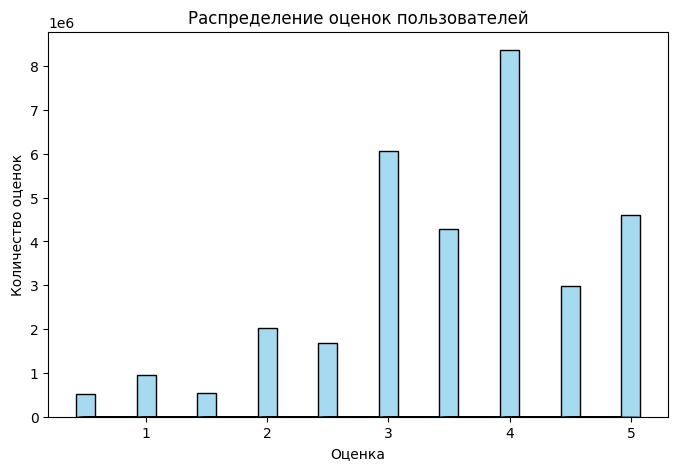

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(ratings["rating"], 
             color='skyblue', 
             shrink=25);
plt.title('Распределение оценок пользователей')
plt.xlabel("Оценка")
plt.ylabel("Количество оценок")
plt.show()

In [4]:
ratings = ratings.merge(movies[["movieId", "title"]], on="movieId", how="left")

rating_mean = ratings["rating"].mean()
#Перевод времени в даты
ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s").dt.date

movies["genres"] = movies["genres"].str.split("|")

#Наиболее активные пользователи
most_act_users = (
    ratings[["userId", "rating"]]
    .groupby(["userId"])
    .count().sort_values(["rating"], ascending=False)
    .reset_index()
    .rename(columns={"rating": "count"}))


#Наиболее популярные фильмы
most_pop = (
    ratings[["rating", "title"]]
    .groupby(["title"]).count()
    .sort_values(["rating"], ascending=False)
    .reset_index().
    rename(columns={"rating": "count"}))

#Фильмы, с лучшими оценками
best_rating = (ratings[["rating", "title", "movieId"]]
               .groupby(["title"]).mean()
               .sort_values(["rating"], ascending=False)
              .reset_index())

movies = movies.drop(columns=["title"]).merge(best_rating, on="movieId")

#Количество оценок по времени
timestamp_rating = (
    ratings
    .assign(month=ratings["date"].dt.to_period("M"))  # выделяем месяц
    .groupby("month")["rating"]
    .count()
    .rename("count")
    .reset_index()
)

/tmp/ipykernel_37/2755741303.py:32: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  movies = movies.drop(columns=["title"]).merge(best_rating, on="movieId")


In [5]:
#Считаем среднюю оценку пользователя фильму и отклонение от этой оценки
ratings = ratings.merge(ratings.groupby("userId")["rating"].mean().rename("mean_user_rating").reset_index(), on="userId")
ratings["user_rating"] = ratings["rating"] - ratings["mean_user_rating"]

movies = movies.merge(ratings.groupby("movieId")["user_rating"].mean().rename("user_rating_bias").reset_index(), on="movieId")

#Считаем количество оценок каждого фильма
movies = movies.merge(ratings.groupby("movieId")["rating"].count().rename("count"), on="movieId")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


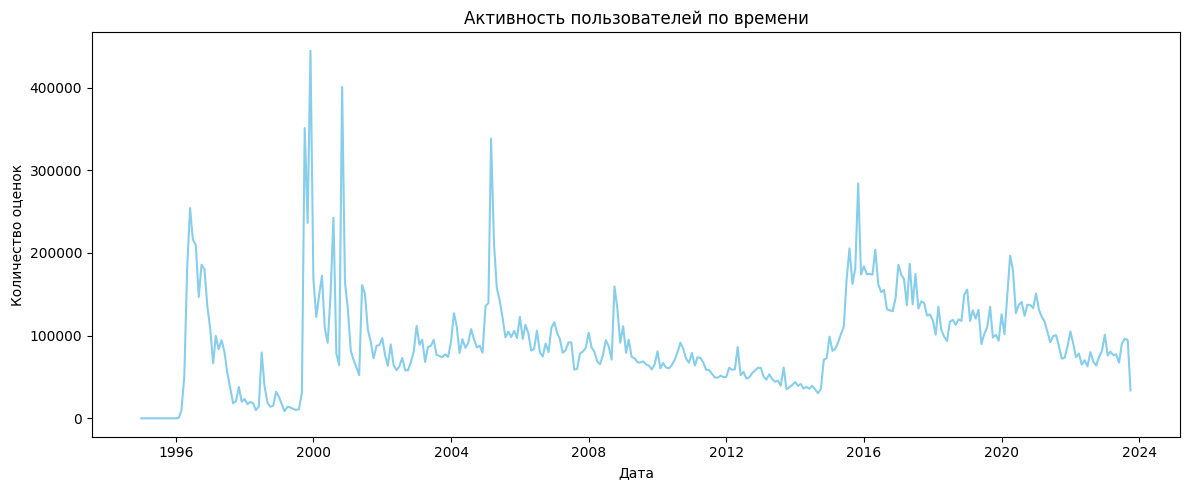

In [45]:
timestamp_rating["month"] = timestamp_rating["month"].astype("datetime64[ns]")

plt.figure(figsize=(12, 5))
sns.lineplot(data=timestamp_rating, x="month", y="count", color="skyblue")

plt.title("Активность пользователей по времени")
plt.xlabel("Дата")
plt.ylabel("Количество оценок")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


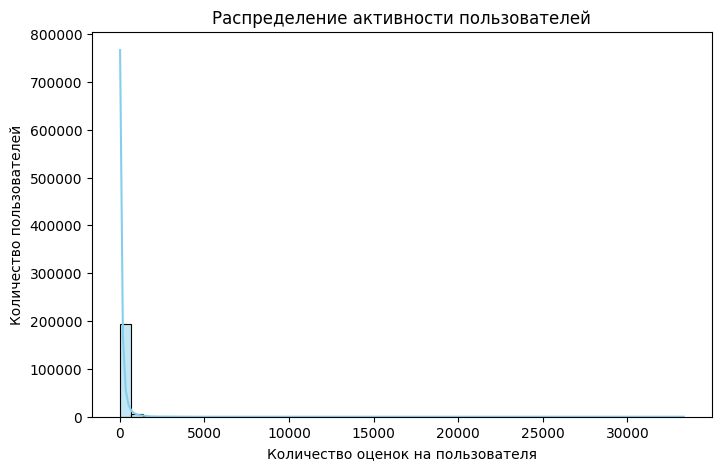

Медианное количество оценок пользователя - 73.0


In [8]:
plt.figure(figsize=(8,5))
sns.histplot(most_act_users["count"], 
             bins=50, 
             kde=True, 
             color="skyblue")
plt.title("Распределение активности пользователей")
plt.xlabel("Количество оценок на пользователя")
plt.ylabel("Количество пользователей")
plt.show()

median_count = most_act_users["count"].median()
print(f"Медианное количество оценок пользователя - {median_count}")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


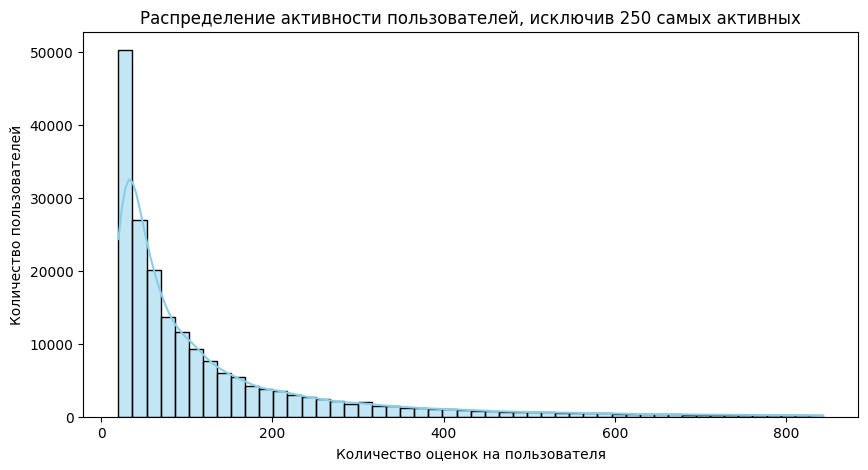

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(most_act_users["count"][5000:],
             bins=50,
             kde=True,
             color="skyblue")
plt.title("Распределение активности пользователей, исключив 250 самых активных")
plt.xlabel("Количество оценок на пользователя")
plt.ylabel("Количество пользователей")
plt.show()

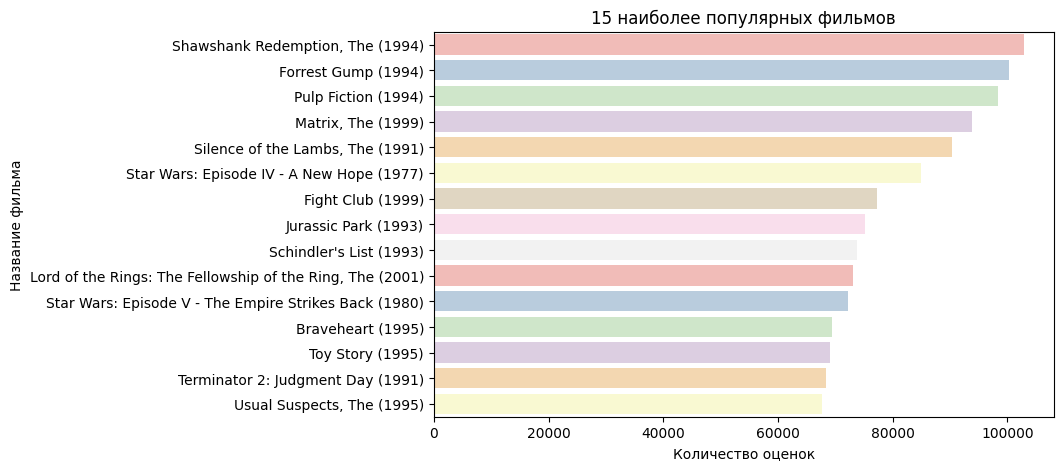

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data=most_pop.head(15),
            x="count",
            y="title",
            palette="Pastel1")
plt.title("15 наиболее популярных фильмов")
plt.xlabel("Количество оценок")
plt.ylabel("Название фильма")
plt.show()

In [18]:
# Работа с жанрами фильмов

genres_list = ["Action", "Adventure", "Animation", "Children", "Comedy", "Crime", "Documentary", "Drama", "Fantasy",
               "Film-Noir", "Horror", "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"]

genres = {"genre": [],
         "number": [],
         "avg rating": []}

for genre in genres_list:
    n = 0
    r = 0

    for idx, row in movies.iterrows():
        if genre in row["genres"]:
            n += 1
            r += movies.loc[idx, "rating"]
            
    genres["genre"] += [genre]
    genres["number"] += [n]
    genres["avg rating"] += [r]
    
genres = pd.DataFrame(genres).sort_values(["number"], ascending=False).reset_index(drop=True)
genres["avg rating"] = genres["avg rating"] / genres["number"]

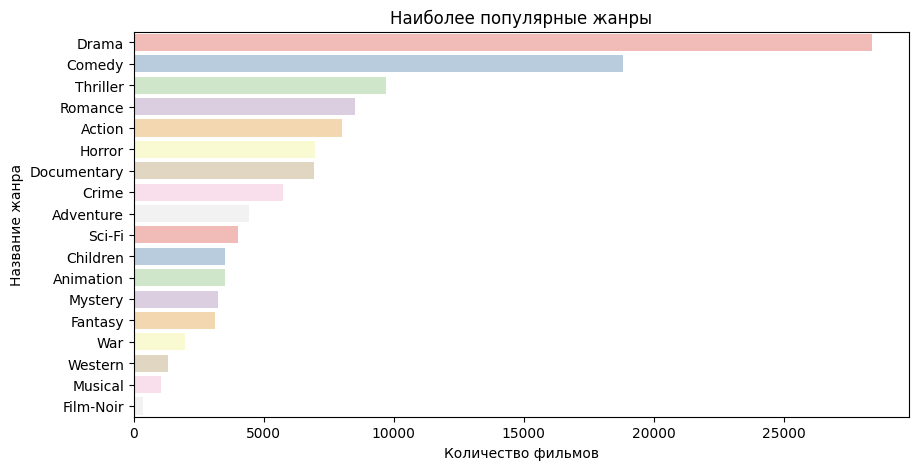

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(data=genres,
            x="number",
            y="genre",
            palette="Pastel1")
plt.title("Наиболее популярные жанры")
plt.xlabel("Количество фильмов")
plt.ylabel("Название жанра")
plt.show()

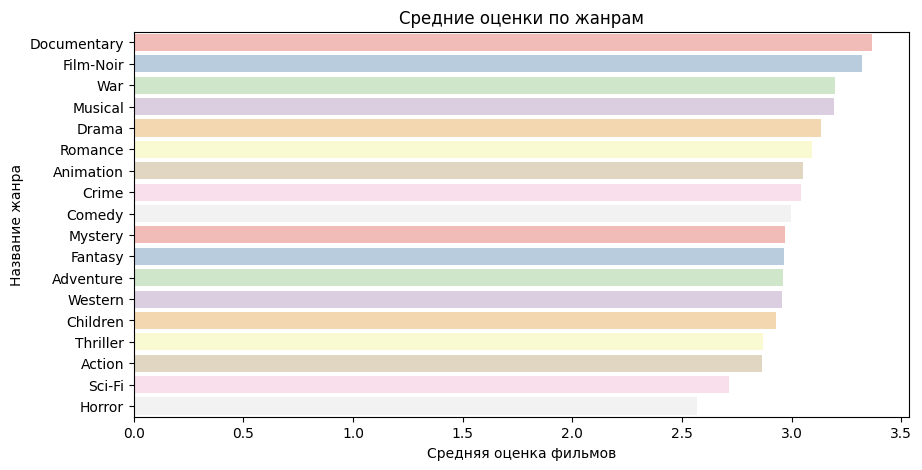

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(data=genres.sort_values(["avg rating"], ascending=False),
            x="avg rating",
            y="genre",
            palette="Pastel1")
plt.title("Средние оценки по жанрам")
plt.xlabel("Средняя оценка фильмов")
plt.ylabel("Название жанра")
plt.show()

In [21]:
#Получаем самый популярный тег по каждому фильму

all_tags = tags["tag"].value_counts().to_dict()

movies_tags = tags[["movieId", "tag"]]

movies_tags = movies_tags.groupby("movieId")["tag"].agg(lambda x: x.value_counts().index[0]).reset_index()

movies = movies.merge(movies_tags, on="movieId")

# Получаем топ 100 самых частых тегов для визуализации

top_tags = [i for i in all_tags.keys()][:100]

tags_rating = movies[movies["tag"].isin(top_tags)].groupby("tag")["rating"].mean(["rating"]).reset_index().sort_values(["rating"], ascending=False)

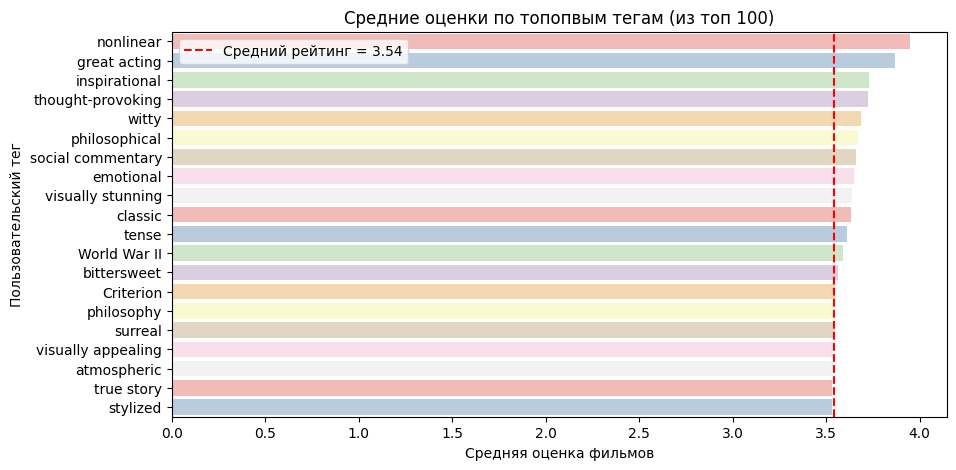

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(data=tags_rating[:20],
            x="rating",
            y="tag",
            palette="Pastel1")
plt.axvline(rating_mean, color="red", linestyle="--", label=f"Средний рейтинг = {rating_mean:.2f}")
plt.title("Средние оценки по топопвым тегам (из топ 100)")
plt.xlabel("Средняя оценка фильмов")
plt.ylabel("Пользовательский тег")
plt.legend()
plt.show()

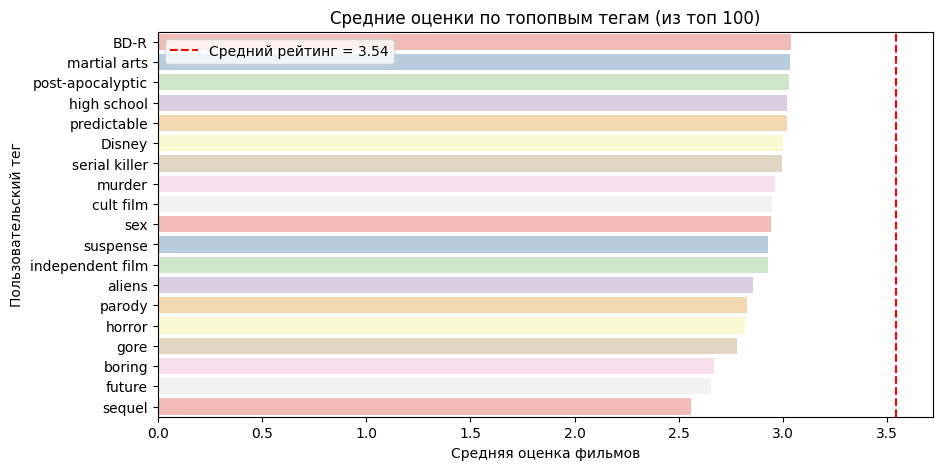

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(data=tags_rating[80:],
            x="rating",
            y="tag",
            palette="Pastel1")
plt.axvline(rating_mean, color="red", linestyle="--", label=f"Средний рейтинг = {rating_mean:.2f}")
plt.title("Средние оценки по топопвым тегам (из топ 100)")
plt.xlabel("Средняя оценка фильмов")
plt.ylabel("Пользовательский тег")
plt.legend()
plt.show()

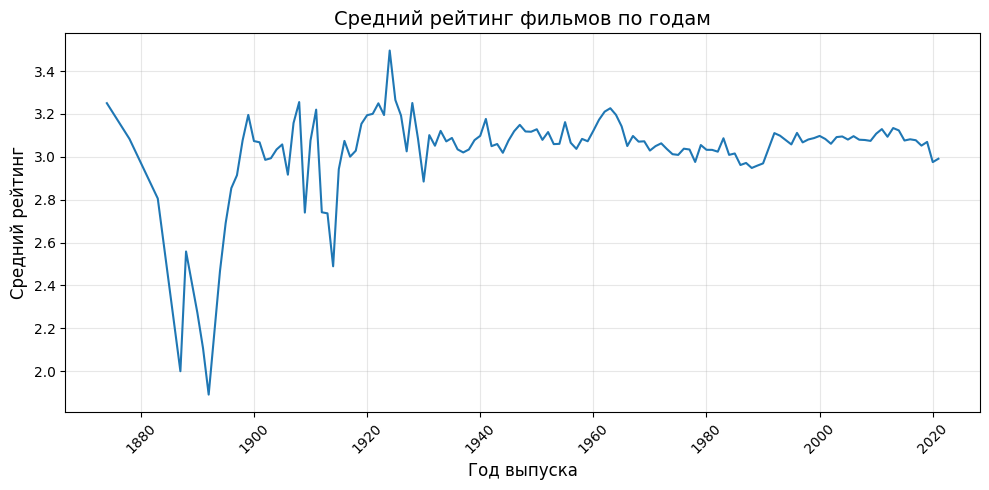

In [24]:
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)").astype(float).astype("Int64")

mean_ratings = movies.groupby("year")["rating"].mean().dropna()

plt.figure(figsize=(10, 5))
plt.plot(mean_ratings.index, mean_ratings.values)

plt.title("Средний рейтинг фильмов по годам", fontsize=14)
plt.xlabel("Год выпуска", fontsize=12)
plt.ylabel("Средний рейтинг", fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

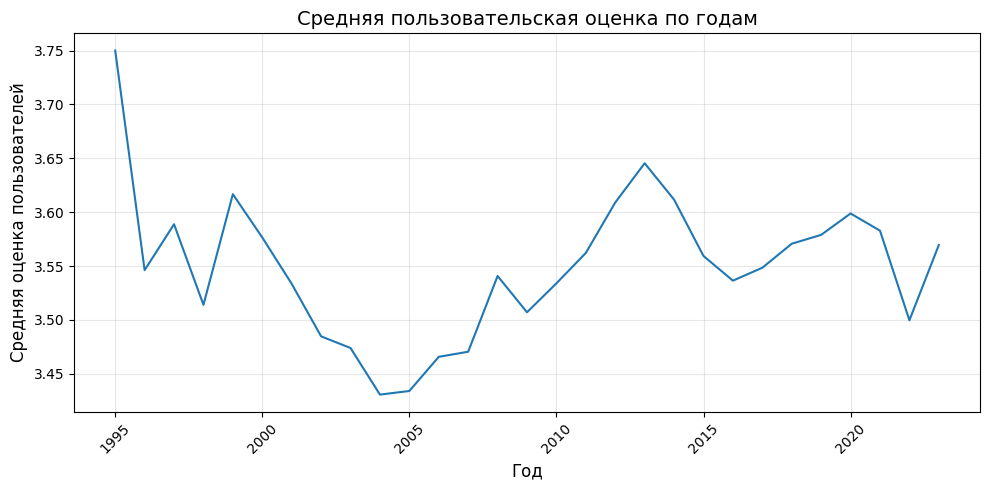

In [25]:
ratings["date"] = pd.to_datetime(ratings["date"])

ratings["year"] = ratings["date"].dt.year

mean_year_rating = ratings.groupby("year")["rating"].mean().dropna()

plt.figure(figsize=(10, 5))
plt.plot(mean_year_rating.index, mean_year_rating.values)

# plt.subplot()
# plt.plot(mean_ratings.index, mean_ratings.values)

plt.title("Средняя пользовательская оценка по годам", fontsize=14)
plt.xlabel("Год", fontsize=12)
plt.ylabel("Средняя оценка пользователей", fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

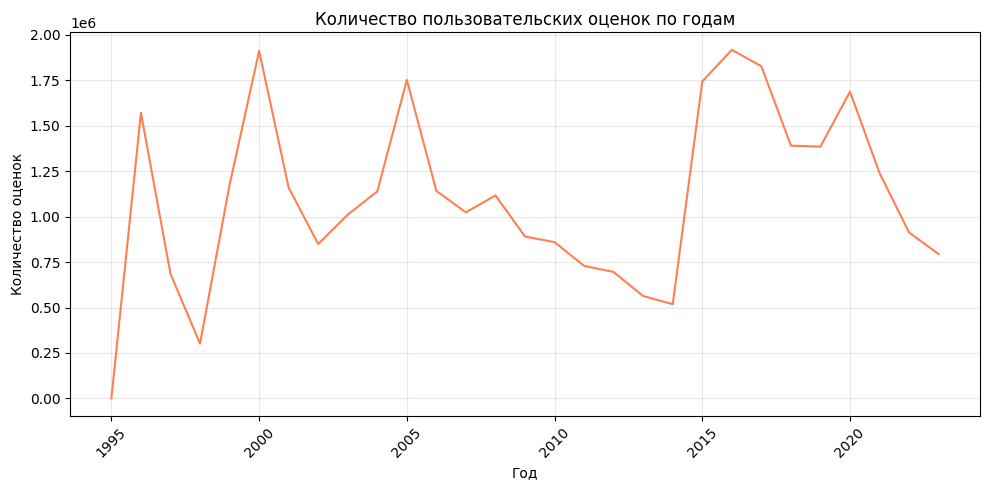

In [26]:
ratings_per_year = ratings.groupby("year")["rating"].count()

plt.figure(figsize=(10, 5))
plt.plot(ratings_per_year.index, ratings_per_year.values,
         color="coral")

# Оформление
plt.title("Количество пользовательских оценок по годам")
plt.xlabel("Год")
plt.ylabel("Количество оценок")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_37/385641150.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 1000x700 with 0 Axes>

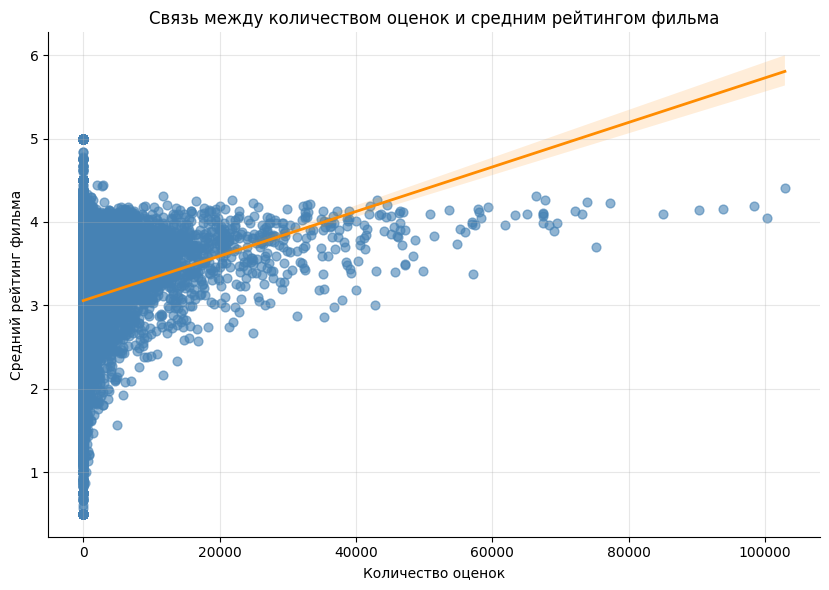

In [27]:
plt.figure(figsize=(10, 7))

sns.lmplot(
    data=movies,
    x="count", y="rating",
    height=6, aspect=1.4,
    scatter_kws={"alpha": 0.6, "s": 40, "color": "steelblue"},
    line_kws={"color": "darkorange", "lw": 2}
)

plt.title("Связь между количеством оценок и средним рейтингом фильма")
plt.xlabel("Количество оценок")
plt.ylabel("Средний рейтинг фильма")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Распределение средних отклонений пользователей')

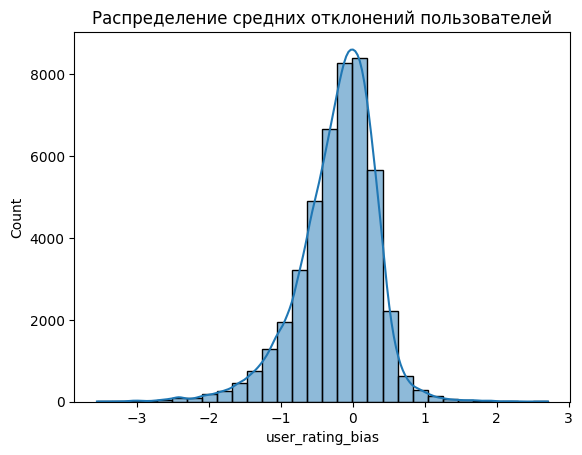

In [28]:
sns.histplot(movies["user_rating_bias"], bins=30, kde=True)
plt.title("Распределение средних отклонений пользователей")

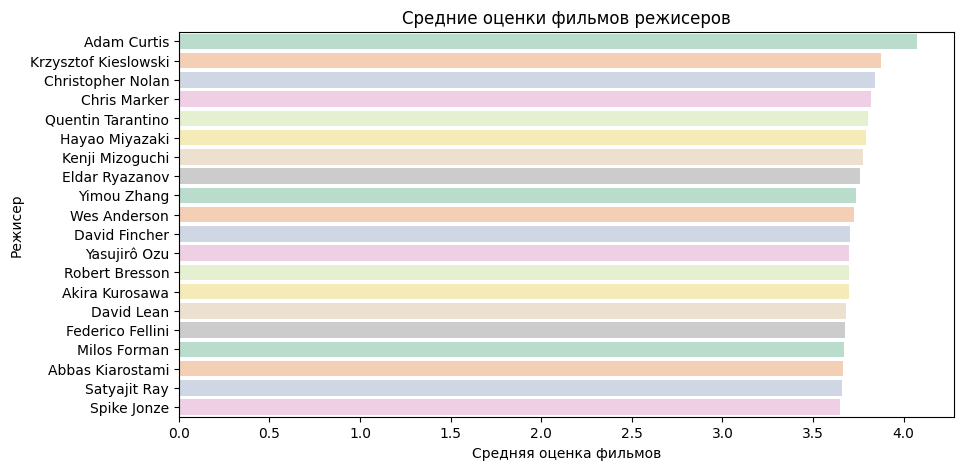

In [29]:
movies_directors = movies.groupby("directedBy")["rating"].agg(["mean", "count"]).reset_index().sort_values("mean", ascending=False)

#Оставим только режисеров, у которых более 20 фильмов
plt.figure(figsize=(10,5))
sns.barplot(data=movies_directors[movies_directors["count"] > 10][:20],
            x="mean",
            y="directedBy",
            palette="Pastel2")
plt.title("Средние оценки фильмов режисеров")
plt.xlabel("Средняя оценка фильмов")
plt.ylabel("Режисер")
plt.show()

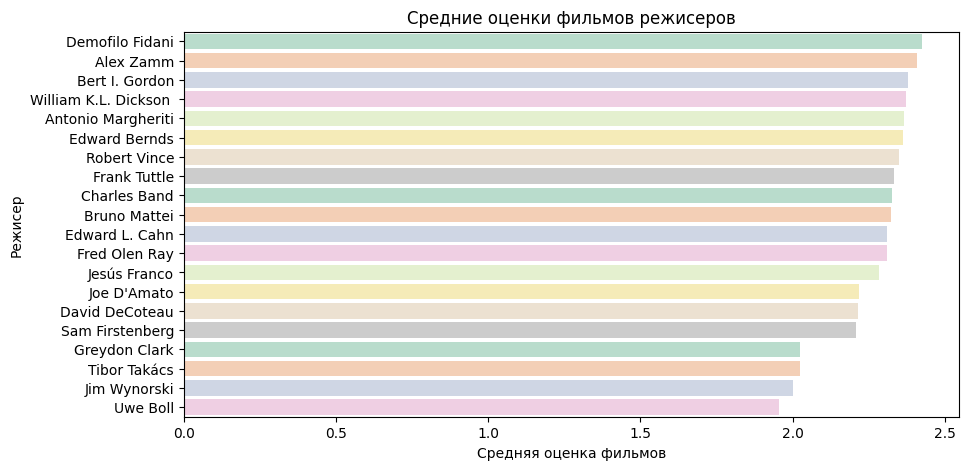

In [30]:
plt.figure(figsize=(10,5))
sns.barplot(data=movies_directors[movies_directors["count"] > 10][-20:],
            x="mean",
            y="directedBy",
            palette="Pastel2")
plt.title("Средние оценки фильмов режисеров")
plt.xlabel("Средняя оценка фильмов")
plt.ylabel("Режисер")
plt.show()

In [31]:
#Фильмы, имеющие менее 10 оценок, не представляют интерес для разработки качественной рекомендательной системы 
movies = movies[movies["count"] > 10]

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Распределение продолжительности фильмов')

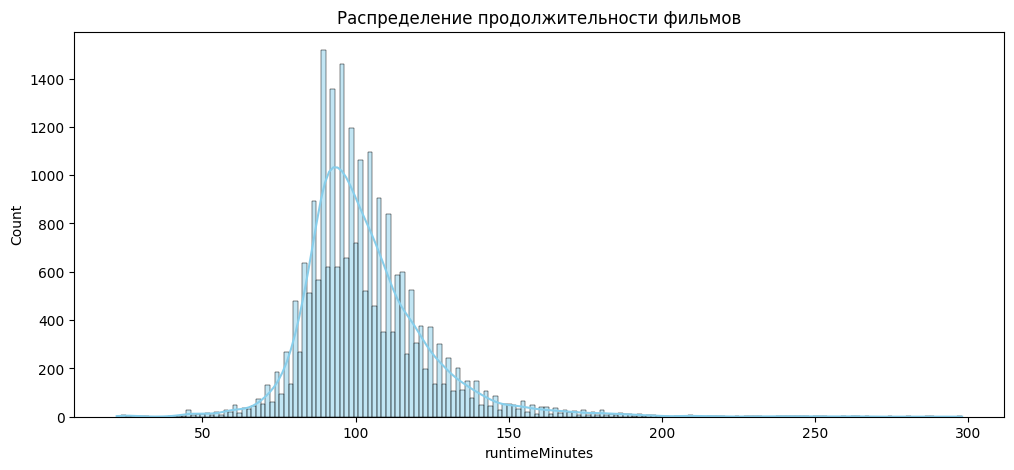

In [32]:
plt.figure(figsize=(12, 5))
sns.histplot(movies["runtimeMinutes"], kde=True, color="skyblue")
plt.title("Распределение продолжительности фильмов")

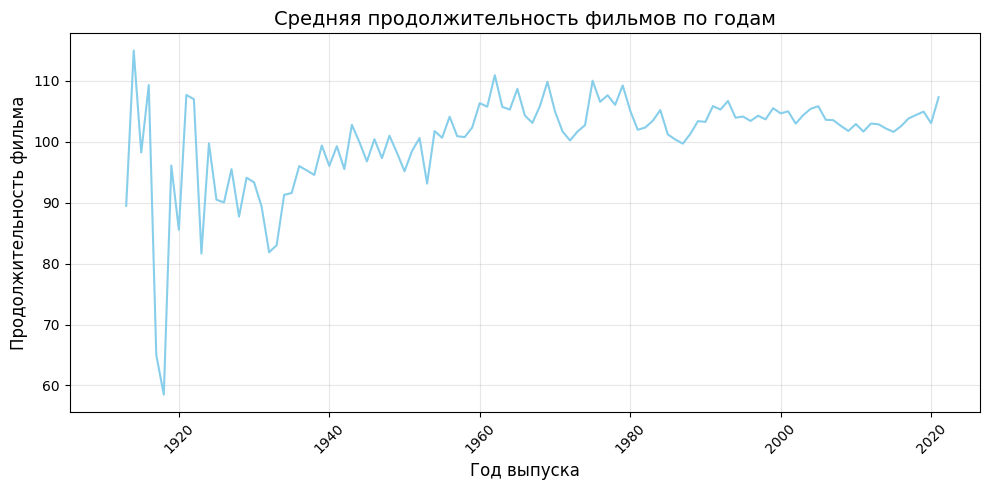

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(movies.groupby("year")["runtimeMinutes"].mean().index,
        movies.groupby("year")["runtimeMinutes"].mean().values,
        color="skyblue")

plt.title("Средняя продолжительность фильмов по годам", fontsize=14)
plt.xlabel("Год выпуска", fontsize=12)
plt.ylabel("Продолжительность фильма", fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# pivot = ratings.merge(movies[["runtimeMinutes", "movieId"]], on="movieId", how="left")

# pivot["duration_bin"] = pd.cut(ratings_pivot["runtimeMinutes"], bins=[0, 60, 90, 120, 150, 180, 300],
#                             labels=["<60", "60-90", "90-120", "120-150", "150-180", "180+"])

# pivot = ratings_pivot.groupby(["year", "duration_bin"])["rating"].mean().reset_index()

# heatmap_data = pivot.pivot(index="duration_bin", columns="year", values="rating")

# plt.figure(figsize=(12, 6))
# sns.heatmap(heatmap_data, cmap="YlOrBr", cbar_kws={'label': 'Средняя оценка'}, annot=True)
# plt.title("Средняя оценка в зависимости от длительности фильма и года")
# plt.xlabel("Год")
# plt.ylabel("Длительность (мин)")
# plt.show()

In [34]:
import re

# Работа с актерским составом

movies["starring"] = movies["starring"].apply(
    lambda x: re.split(r",\s*", x.strip()) if isinstance(x, str) else []
)

actors = {}

# Проходим по всем фильмам
for idx, row in movies.iterrows():
    # У каждого фильма список актёров
    for actor in row["starring"]:
        if actor not in actors:
            actors[actor] = {"number": 0, "sum_rating": 0}
        actors[actor]["number"] += 1
        actors[actor]["sum_rating"] += row["rating"]

# Преобразуем в DataFrame
actors_df = pd.DataFrame([
    {"actor": actor, 
     "number": data["number"], 
     "avg rating": data["sum_rating"] / data["number"]}
    for actor, data in actors.items()
])

# Сортируем по числу фильмов
actors_df = actors_df.sort_values("number", ascending=False).reset_index(drop=True)

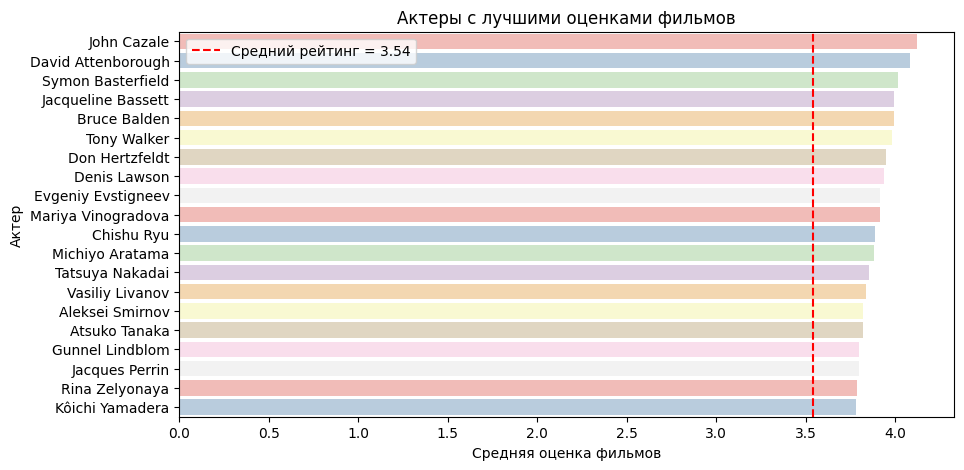

In [35]:
plt.figure(figsize=(10,5))
sns.barplot(data=actors_df[actors_df["number"] > 5].sort_values("avg rating", ascending=False)[:20],
            x="avg rating",
            y="actor",
            palette="Pastel1")
plt.axvline(rating_mean, color="red", linestyle="--", label=f"Средний рейтинг = {rating_mean:.2f}")
plt.title("Актеры с лучшими оценками фильмов")
plt.xlabel("Средняя оценка фильмов")
plt.ylabel("Актер")
plt.legend()
plt.show()

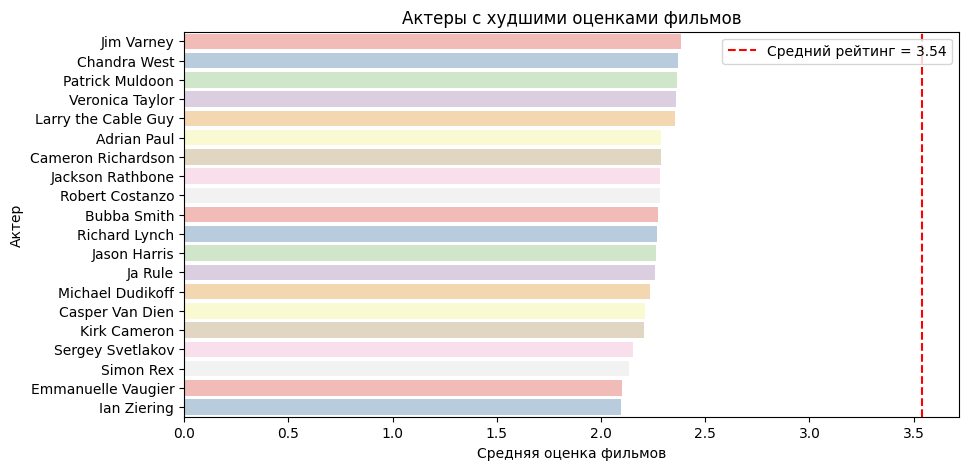

In [36]:
plt.figure(figsize=(10,5))
sns.barplot(data=actors_df[actors_df["number"] > 5].sort_values("avg rating", ascending=False)[-20:],
            x="avg rating",
            y="actor",
            palette="Pastel1")
plt.axvline(rating_mean, color="red", linestyle="--", label=f"Средний рейтинг = {rating_mean:.2f}")
plt.title("Актеры с худшими оценками фильмов")
plt.xlabel("Средняя оценка фильмов")
plt.ylabel("Актер")
plt.legend()
plt.show()

<center>ВЫВОДЫ ПО EDA<center>

Все данные представлены в 3 основных датасетах: 

ratings - содержит более 32 млн оценок пользователей по 5 бальной шкале и шагом 0.5, у каждой оценки есть временная метка. Рейтинги фильмов распределены неравномерно - самая частая оценка - 4 балла, средняя 3.54, однако конечно для каждого пользователя оценки не равнозначны, для этого было посчитано отклонение каждой оценки пользователя от его средней оценки. Был произведен анализ активности пользователей, активность неравномерна, первые оценки в 1996 ставились всего 4 пользователями, далее количество росло, также и росло количество оценок в год, Также видно, что пользователи разные по активности: абсолютное большинство имеет менее 100 оценок, однако есть единичне пользователи, имеющие более 1000 оценок.
Далее по количеству оценок выделены наиболее популярные фильмы, так, самый популярный - Побег из Шоушенка (1994). Был построен график зависимости года выхода фильма от его рейтинга, до 1950 график ведет себя скачкообразно, это связанно с низким числом фильмов в эти годы, потом он в целом стабилизируется и начиная с 2018 года рейтинги фильмов в среднем падают.

movies - список всех фильмов (73476 строк), содержит такие данные как название, год выхода, длительность, режисер, основные актеры и др. Произведен анализ жанров фильмов, оказалось, что жанры распределены крайне неравномерно, большинство фильмов сняты в жанре драма и комедия, а самые редкие - мьюзикл и нуар. Посчитаны средние оценки по жанрам фильмов, оказалось самые успешные - документальные фильмы, а наименее - ужасы. Также был построен график зависимости рейтинга фильма от его популярности, оказалось, что количество оценок фильма коррелирует с его рейтингом. Также был проведен анализ зависимости оценки фильма от его режисера и актеров, оказалось, что и режисеры, и актеры вносят большой вклад в оценку фильма, это все отражено в визуализации.

tags - более 2 млн тегов, которые пользователи ставили фильмам. Были составленые списки тегов по каждому фильму и их частота. В ходе EDA были взяты самые частые теги по каждому фильму, проведен анализ влияния тега на рейтинг фильма. Оказалось, что фильмы с тегами nonlinear и great acting имеют лучший рейтинг, а, например, sequel имеют рейтинг более чем на 1 ниже, чем в среднем по всем фильмам. В будущем планируется для анализа тегов использовать такие языковые модели как BERT, для кластеризации тегов по смыслу.

Таким образом, данные имеют большой потенциал для построения гибридной модели рекомендательной системы.